In [120]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [169]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

import sys; sys.path.insert(0, "../src")
from preprocessing import nettoyer, preparer, COLS_FUITE

# Partie A:  Audit et nettoyage

*Exploration*

In [122]:
df = pd.read_csv('../data/points_eau.csv')
print(f"\n shape : {df.shape} ")
print(f"\n columns : {df.columns.to_list() } ")
print(f"Manquants : {df.isnull().sum().sum()} valeurs / {df.isnull().mean().mean()*100:.1f}% du total")
print(f"Types     : \n{df.dtypes.value_counts()}")
print(f"info : {df.info()}")
print("\n description :", df.describe())


 shape : (11472, 32) 

 columns : ['id_point_eau', 'date_releve', 'departement', 'commune', 'latitude', 'longitude', 'altitude_m', 'annee_construction', 'type_ouvrage', 'type_pompe', 'profondeur_forage_m', 'niveau_statique_m', 'debit_essai_m3_h', 'qualite_eau', 'nb_menages', 'population_desservie', 'distance_village_m', 'nb_points_eau_village', 'mode_gestion', 'mode_paiement', 'cotisation_mensuelle_fcfa', 'technicien_forme_village', 'stock_pieces_rechange_commune', 'distance_atelier_km', 'maitre_ouvrage', 'installateur', 'nb_pannes_12_mois', 'mois_depuis_derniere_maintenance', 'nb_jours_arret_12_mois', 'intervention_prevue', 'cout_reparation_estime_fcfa', 'etat_fonctionnement'] 
Manquants : 5515 valeurs / 1.5% du total
Types     : 
str        13
float64    13
int64       6
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 11472 entries, 0 to 11471
Data columns (total 32 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                 

# A1. Tableau des valeurs manquantes

In [123]:
tableau = pd.DataFrame({
    "n_manquants": df.isna().sum(),
    "taux_%": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})
tableau = tableau[tableau["n_manquants"] > 0].sort_values("taux_%", ascending=False)

print(f"Cellules vides   : {df.isna().sum().sum() / df.size * 100:.2f} % du tableau")
print(f"Lignes complètes : {df.notna().all(axis=1).mean()*100:.1f} %  "
      f"(supprimer les lignes trouées coûterait {(1-df.notna().all(axis=1).mean())*100:.0f} % du jeu)")
display(tableau)

Cellules vides   : 1.50 % du tableau
Lignes complètes : 60.3 %  (supprimer les lignes trouées coûterait 40 % du jeu)


,n_manquants,taux_%,dtype
niveau_statique_m,1679,14.64,float64
debit_essai_m3_h,1056,9.21,float64
mois_depuis_derniere_maintenance,896,7.81,float64
altitude_m,698,6.08,float64
nb_menages,480,4.18,float64
qualite_eau,406,3.54,str
cotisation_mensuelle_fcfa,300,2.62,float64


In [124]:
# COLS_CAT = [c for c in df.select_dtypes(include=["object", "string", "category"]).columns   if c != "id_point_eau"]
COLS_CAT = [c for c in df.select_dtypes(include=["object", "string", "category"]).columns
            if c not in ("id_point_eau", "etat_fonctionnement", "date_releve")]

COLS_NUM = df.select_dtypes(include=["number"]).columns.to_list()

print("Categorielles :", COLS_CAT)
print("Numeriques    :", COLS_NUM)

Categorielles : ['departement', 'commune', 'type_ouvrage', 'type_pompe', 'qualite_eau', 'mode_gestion', 'mode_paiement', 'maitre_ouvrage', 'installateur', 'intervention_prevue']
Numeriques    : ['latitude', 'longitude', 'altitude_m', 'annee_construction', 'profondeur_forage_m', 'niveau_statique_m', 'debit_essai_m3_h', 'nb_menages', 'population_desservie', 'distance_village_m', 'nb_points_eau_village', 'cotisation_mensuelle_fcfa', 'technicien_forme_village', 'stock_pieces_rechange_commune', 'distance_atelier_km', 'nb_pannes_12_mois', 'mois_depuis_derniere_maintenance', 'nb_jours_arret_12_mois', 'cout_reparation_estime_fcfa']


In [125]:
def diagnostic_manquants(df, col, cols_cat=COLS_CAT, cols_num=COLS_NUM, alpha=0.05):

    mask = df[col].isna()
    print("=" * 78)
    print(f" {col} - {mask.sum()} manquants ({mask.mean()*100:.1f} %)")
    print("=" * 78)

    lignes = []
    for c in cols_cat:
        if c == col:
            continue
        tab = pd.crosstab(df[c], mask)
        if tab.shape[0] < 2 or tab.shape[1] < 2:
            continue
        lignes.append({"variable": c, "type": "cat", "p_value": chi2_contingency(tab)[1]})

    for c in cols_num:
        if c == col:
            continue
        a = df.loc[~mask, c].dropna()
        b = df.loc[mask, c].dropna()
        if len(b) < 10:
            continue
        lignes.append({"variable": c, "type": "num", "p_value": mannwhitneyu(a, b).pvalue})

    res = pd.DataFrame(lignes).sort_values("p_value").reset_index(drop=True)
    n_tests = len(res)
    seuil_bonf = alpha / n_tests
    res["p_value"] = res["p_value"].round(4)
    res["brut"] = np.where(res["p_value"] < alpha, "LIE", "indep.")
    res["corrige"] = np.where(res["p_value"] < seuil_bonf, "LIE", "indep.")
    print(f"{n_tests} tests  seuil brut {alpha}, seuil Bonferroni {seuil_bonf:.4f}")
    print(res.to_string(index=False))

    med = df.groupby(mask)[[c for c in cols_num if c != col]].median().T
    med.columns = ["complet", "manquant"]
    med["ecart_%"] = ((med["manquant"] / med["complet"] - 1) * 100).round(1)
    print("\nMédianes comparées :")
    print(med.round(1).to_string())


    repartition = (pd.crosstab(mask, df["etat_fonctionnement"], normalize="index") * 100).round(1)
    repartition.index = ["complet", "manquant"]
    effectifs = mask.value_counts().reindex([False, True]).values

    p_cible = chi2_contingency(pd.crosstab(df["etat_fonctionnement"], mask))[1]
    print(f"\nRepartition de la cible (%)  n = {effectifs[0]} / {effectifs[1]} :")
    print(repartition.to_string())
    print(f"p = {p_cible:.4f} -> l'absence est "
          f"{'INFORMATIVE' if p_cible < alpha else 'non informative'} sur la cible\n")
    return res



In [126]:
resultats = {}
for col in tableau.index:
    resultats[col] = diagnostic_manquants(df, col)

 niveau_statique_m - 1679 manquants (14.6 %)
28 tests  seuil brut 0.05, seuil Bonferroni 0.0018
                        variable type  p_value   brut corrige
                      nb_menages  num   0.0172    LIE  indep.
            population_desservie  num   0.0206    LIE  indep.
                    installateur  cat   0.0208    LIE  indep.
             distance_atelier_km  num   0.0253    LIE  indep.
           nb_points_eau_village  num   0.0421    LIE  indep.
               nb_pannes_12_mois  num   0.1625 indep.  indep.
             intervention_prevue  cat   0.1843 indep.  indep.
                debit_essai_m3_h  num   0.2069 indep.  indep.
mois_depuis_derniere_maintenance  num   0.2134 indep.  indep.
        technicien_forme_village  num   0.2191 indep.  indep.
                         commune  cat   0.2244 indep.  indep.
     cout_reparation_estime_fcfa  num   0.2328 indep.  indep.
   stock_pieces_rechange_commune  num   0.2797 indep.  indep.
              distance_village_m  nu

# A2. Détection de doublons et traitement

In [127]:
n_doublons = df.duplicated().sum()
print(f"Doublons : {n_doublons}  " )

Doublons : 65  


In [128]:
n_doublons_id = df["id_point_eau"].duplicated().sum()
print(f"Doublons sur id point d'eau : {n_doublons_id}  " )

Doublons sur id point d'eau : 72  


In [129]:
doublons = df[df.duplicated(keep=False)].sort_values("id_point_eau")
print(f"Lignes impliquées : {len(doublons)}")
display(doublons.head(6))

Lignes impliquées : 130


,id_point_eau,date_releve,departement,commune,latitude,longitude,altitude_m,annee_construction,type_ouvrage,type_pompe,...,stock_pieces_rechange_commune,distance_atelier_km,maitre_ouvrage,installateur,nb_pannes_12_mois,mois_depuis_derniere_maintenance,nb_jours_arret_12_mois,intervention_prevue,cout_reparation_estime_fcfa,etat_fonctionnement
695,PE-000051,2025-11-20,Borgou,N'Dali,9.22114,2.80126,214.9,2021,Poste d'eau autonome,Immergee electrique,...,0,26.7,ONG internationale,ENT-008,0,7.0,12.0,Aucune,0.0,fonctionnel
4264,PE-000051,2025-11-20,Borgou,N'Dali,9.22114,2.80126,214.9,2021,Poste d'eau autonome,Immergee electrique,...,0,26.7,ONG internationale,ENT-008,0,7.0,12.0,Aucune,0.0,fonctionnel
8843,PE-000759,2025-11-02,Borgou,Parakou,9.91264,3.02302,NaN,1995,Forage equipe PMH,India Mark II,...,1,8.9,Etat,ENT-023,0,NaN,1.0,Aucune,0.0,fonctionnel
9127,PE-000759,2025-11-02,Borgou,Parakou,9.91264,3.02302,NaN,1995,Forage equipe PMH,India Mark II,...,1,8.9,Etat,ENT-023,0,NaN,1.0,Aucune,0.0,fonctionnel
5840,PE-001074,2025-09-11,Zou,Bohicon,7.08139,2.53166,183.4,2006,Puits traditionnel ameliore,Aucune (puisage manuel),...,0,53.4,Etat,ENT-023,1,8.0,1.0,Aucune,0.0,fonctionnel
2984,PE-001074,2025-09-11,Zou,Bohicon,7.08139,2.53166,183.4,2006,Puits traditionnel ameliore,Aucune (puisage manuel),...,0,53.4,Etat,ENT-023,1,8.0,1.0,Aucune,0.0,fonctionnel


In [130]:
n_ids_hors_doublons_exacts = df.drop_duplicates()["id_point_eau"].duplicated().sum()
print(f"id_point_eau encore répétés après suppression des doublons exacts : "
      f"{n_ids_hors_doublons_exacts}")

id_point_eau encore répétés après suppression des doublons exacts : 7


In [131]:
avant = len(df)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print(f"{avant} -> {len(df)} lignes ({avant - len(df)} supprimees)")

print("\nRepartition de la cible :")
print(df["etat_fonctionnement"].value_counts(normalize=True).mul(100).round(1).to_string())


11472 -> 11407 lignes (65 supprimees)

Repartition de la cible :
etat_fonctionnement
fonctionnel              54.8
en panne                 37.2
fonctionnel a reparer     8.0


# A3. Les valeurs sentinelles

In [132]:
VALEURS_MAGIQUES = {-1, 0, -9, -99, -999, -9999, 999, 9999, 99999, -888, 888}

def detecter_sentinelles(df, cible="etat_fonctionnement", seuil_trou=3):
    lignes = []
    for c in df.select_dtypes(include=[np.number]).columns.drop(cible, errors="ignore"):
        s = df[c].dropna()
        u = np.sort(s.unique())
        if len(u) < 3:
            continue
        iqr = s.quantile(0.75) - s.quantile(0.25) or s.std()
        for v, voisin in [(u[0], u[1]), (u[-1], u[-2])]:
            trou = abs(v - voisin) / iqr
            motifs = []
            if v in VALEURS_MAGIQUES:  motifs.append("nombre magique")
            if v < 0:                  motifs.append("negatif impossible")
            if trou > seuil_trou:      motifs.append("valeur isolee")
            if motifs:
                lignes.append({"colonne": c, "valeur": v, "n": int((s == v).sum()),
                               "trou_en_IQR": round(trou, 1), "motifs": ", ".join(motifs)})
    return pd.DataFrame(lignes)

display(detecter_sentinelles(df))

,colonne,valeur,n,trou_en_IQR,motifs
0,latitude,0.000000,214,1.8,nombre magique
1,longitude,0.000000,214,0.7,nombre magique
2,annee_construction,0.000000,168,90.1,"nombre magique, valeur isolee"
3,niveau_statique_m,7451.525683,1,370.8,valeur isolee
4,debit_essai_m3_h,-1.000000,62,0.5,"nombre magique, negatif impossible"
5,population_desservie,0.000000,95,0.1,nombre magique
6,cotisation_mensuelle_fcfa,0.000000,3006,0.1,nombre magique
7,nb_pannes_12_mois,0.000000,3379,0.5,nombre magique
8,mois_depuis_derniere_maintenance,0.000000,14,0.1,nombre magique
9,nb_jours_arret_12_mois,0.000000,599,0.0,nombre magique


In [133]:
SENTINELLES = {
    "latitude": [0.0], "longitude": [0.0],
    "annee_construction": [0], "population_desservie": [0],
    "debit_essai_m3_h": [-1],
}
for col, valeurs in SENTINELLES.items():
    n = df[col].isin(valeurs).sum()
    df[col] = df[col].replace(valeurs, np.nan)
    print(f"{col:<24} {n:>4} sentinelle(s) -> NaN   "
          f"(manquants : {df[col].isna().sum()}, soit {df[col].isna().mean()*100:.1f} %)")


latitude                  214 sentinelle(s) -> NaN   (manquants : 214, soit 1.9 %)
longitude                 214 sentinelle(s) -> NaN   (manquants : 214, soit 1.9 %)
annee_construction        168 sentinelle(s) -> NaN   (manquants : 168, soit 1.5 %)
population_desservie       95 sentinelle(s) -> NaN   (manquants : 95, soit 0.8 %)
debit_essai_m3_h           62 sentinelle(s) -> NaN   (manquants : 1115, soit 9.8 %)


In [134]:
print(df[[    "latitude",
    "longitude",
    "annee_construction",
    "population_desservie",
    "debit_essai_m3_h"]].describe().round(1))
print()
print("Sentinelles restantes :", len(detecter_sentinelles(df)))

       latitude  longitude  annee_construction  population_desservie  \
count   11193.0    11193.0             11239.0               11312.0   
mean        8.1        2.2              2003.2                 443.8   
std         1.7        0.5                12.4                 296.7   
min         5.3        0.5              1982.0                  20.0   
25%         6.7        1.8              1992.0                 229.0   
50%         7.3        2.2              2003.0                 376.0   
75%         9.7        2.6              2014.0                 588.0   
max        12.3        3.9              2024.0                3222.0   

       debit_essai_m3_h  
count           10292.0  
mean                3.2  
std                 2.1  
min                 0.2  
25%                 1.7  
50%                 2.7  
75%                 4.2  
max                16.8  

Sentinelles restantes : 6


# A4. Erreur d'unité

In [135]:
print(df["profondeur_forage_m"].describe())

mask_cm = df["profondeur_forage_m"] > 200

print("Nombre de valeurs à convertir :", mask_cm.sum())

df.loc[mask_cm, "profondeur_forage_m"] /= 100
print(f"Apres correction : {df.profondeur_forage_m.min():.1f} a "
      f"{df.profondeur_forage_m.max():.1f} m")

count    11407.000000
mean        98.023898
std        558.376915
min          5.000000
25%         31.200000
50%         53.200000
75%         71.600000
max      11050.000000
Name: profondeur_forage_m, dtype: float64
Nombre de valeurs à convertir : 104
Apres correction : 5.0 a 161.2 m


# A5. Incohérence physique

In [136]:
mask_incoherent = (
    df["niveau_statique_m"] > df["profondeur_forage_m"]
)

print("Nombre de lignes incohérentes :", mask_incoherent.sum())

Nombre de lignes incohérentes : 78


In [137]:
df.loc[
    mask_incoherent,
    ["niveau_statique_m", "profondeur_forage_m"]
]

,niveau_statique_m,profondeur_forage_m
35,31.848397,5.0
111,19.281303,5.0
272,66.808422,41.0
337,55.206050,34.9
338,101.286243,78.0
...,...,...
10911,88.166272,54.5
10937,60.603351,42.2
10975,46.058284,28.7
11094,60.845944,34.3


In [138]:
df.loc[
    mask_incoherent,
    "niveau_statique_m"
].describe()

count      78.000000
mean      162.991470
std       836.483592
min         9.705628
25%        49.867704
50%        68.382821
75%        86.828149
max      7451.525683
Name: niveau_statique_m, dtype: float64

In [139]:
df.loc[
    mask_incoherent,
    ["niveau_statique_m", "profondeur_forage_m"]
].assign(
    ecart=lambda x:
        x["niveau_statique_m"] - x["profondeur_forage_m"]
)

,niveau_statique_m,profondeur_forage_m,ecart
35,31.848397,5.0,26.848397
111,19.281303,5.0,14.281303
272,66.808422,41.0,25.808422
337,55.206050,34.9,20.306050
338,101.286243,78.0,23.286243
...,...,...,...
10911,88.166272,54.5,33.666272
10937,60.603351,42.2,18.403351
10975,46.058284,28.7,17.358284
11094,60.845944,34.3,26.545944


In [140]:
df.loc[
    mask_incoherent,
    "niveau_statique_m"
] = np.nan

# A6. Harmonisez les libellés

In [141]:

for colonne in COLS_CAT:
    print("\n", )
    display(df[colonne].value_counts())

departement
Atlantique      1383
Zou             1380
Borgou          1341
Oueme           1204
Atacora         1072
Collines         976
Couffo           846
Alibori          785
Plateau          763
Mono             753
Donga            644
  Zou             40
  Borgou          34
  Atacora         30
  Oueme           29
  Atlantique      26
  Donga           19
  Mono            18
  Collines        18
  Couffo          17
  Alibori         16
  Plateau         13
Name: count, dtype: int64

commune
So-Ava          188
N'Dali          184
Agbangnizoun    184
Parakou         183
Toffo           180
               ... 
ZOGBODOMEY        2
BOHICON           2
PERERE            2
GOGOUNOU          2
KLOUEKANME        1
Name: count, Length: 152, dtype: int64

type_ouvrage
Forage equipe PMH              5029
Puits moderne                  2171
Adduction d'eau villageoise    1725
Poste d'eau autonome           1612
Puits traditionnel ameliore     870
Name: count, dtype: int64

type_pompe
India Mark II              3152
Aucune (puisage manuel)    2202
Immergee solaire           1919
Vergnet                    1467
Immergee electrique         910
Volanta                     708
Kardia                      506
Immergee thermique          484
india mark 2                 35
Immergee Solaire             24
Name: count, dtype: int64

qualite_eau
Potable         6923
Ferrugineuse    1703
Turbide          996
Saumatre         831
Fluoree          555
Name: count, dtype: int64

mode_gestion
Comite de gestion villageois     5160
Delegataire prive                2358
Aucune gestion formelle          2008
Gestion communale                1767
comite de gestion  villageois      83
AUCUNE GESTION FORMELLE            31
Name: count, dtype: int64

mode_paiement
Au volume              4311
Cotisation annuelle    3497
Gratuit                3080
Forfait mensuel         519
Name: count, dtype: int64

maitre_ouvrage
Commune                    3173
Etat                       2573
ONG internationale         2148
Cooperation bilaterale     1790
Association villageoise    1024
Prive                       699
Name: count, dtype: int64

installateur
ENT-011    251
ENT-041    251
ENT-046    240
ENT-044    239
ENT-050    238
ENT-007    235
ENT-016    234
ENT-018    234
ENT-035    233
ENT-052    233
ENT-014    233
ENT-032    232
ENT-042    229
ENT-036    228
ENT-051    227
ENT-028    226
ENT-026    226
ENT-045    226
ENT-027    225
ENT-008    225
ENT-021    225
ENT-031    224
ENT-023    224
ENT-029    222
ENT-048    221
ENT-034    221
ENT-017    220
ENT-022    220
ENT-033    218
ENT-002    217
ENT-040    215
ENT-038    215
ENT-024    215
ENT-043    212
ENT-039    212
ENT-020    211
ENT-037    210
ENT-019    210
ENT-001    209
ENT-003    209
ENT-012    208
ENT-013    207
ENT-009    206
ENT-025    205
ENT-010    203
ENT-049    202
ENT-005    201
ENT-004    201
ENT-030    201
ENT-015    197
ENT-047    195
ENT-006    186
Name: count, dtype: int64

intervention_prevue
Aucune                    6254
Rehabilitation lourde     2085
Remplacement de pompe     1750
Reparation legere          523
Abandon                    407
Remplacement de pieces     388
Name: count, dtype: int64

In [142]:
SYNONYMES = {
    "type_pompe": {"India mark ii": "India mark 2"}
}
def normaliser(s):
    return (s.str.strip()
             .str.replace(r"\s+", " ", regex=True)
             .str.normalize("NFKD")
             .str.encode("ascii", "ignore").str.decode("utf-8")
             .str.capitalize())

for col in COLS_CAT:
    if col in SYNONYMES:
        df[col] = df[col].replace(SYNONYMES[col])

for col in COLS_CAT:
    df[col] = normaliser(df[col])




parsing des dates

In [143]:
brut = df["date_releve"].astype(str)
est_fr = brut.str.match(r"^\d{2}/\d{2}/\d{4}$")
p1 = brut[est_fr].str.slice(0, 2).astype(int)
p2 = brut[est_fr].str.slice(3, 5).astype(int)
print(f"ISO {(~est_fr).sum()} | FR {est_fr.sum()}")
print(f"position1 > 12 : {(p1>12).sum()}  position2 > 12 : {(p2>12).sum()}  ambigues : {((p1<=12)&(p2<=12)).sum()}")


df["date_releve"] = pd.to_datetime(df["date_releve"], format="mixed", dayfirst=True)
assert df["date_releve"].isna().sum() == 0

df["annee_releve"]     = df["date_releve"].dt.year
df["mois_releve"]      = df["date_releve"].dt.month
df["trimestre_releve"] = df["date_releve"].dt.quarter
df["periode_releve"]   = df["date_releve"].dt.to_period("Q").astype(str)

print(df["date_releve"].min().date(), "->", df["date_releve"].max().date())
print(df["annee_releve"].value_counts().sort_index().to_string())

ISO 11067 | FR 340
position1 > 12 : 195  position2 > 12 : 0  ambigues : 145
2025-01-02 -> 2025-12-11
annee_releve
2025    11407


In [144]:
for colonne in COLS_CAT:
    print("\n", )
    print(df[colonne].value_counts())







departement
Zou           1420
Atlantique    1409
Borgou        1375
Oueme         1233
Atacora       1102
Collines       994
Couffo         863
Alibori        801
Plateau        776
Mono           771
Donga          663
Name: count, dtype: int64


commune
So-ava          192
N'dali          191
Parakou         191
Agbangnizoun    189
Toffo           185
               ... 
Toucountouna    116
Natitingou      114
Athieme         112
Gogounou        106
Kerou           104
Name: count, Length: 76, dtype: int64


type_ouvrage
Forage equipe pmh              5029
Puits moderne                  2171
Adduction d'eau villageoise    1725
Poste d'eau autonome           1612
Puits traditionnel ameliore     870
Name: count, dtype: int64


type_pompe
India mark ii              3152
Aucune (puisage manuel)    2202
Immergee solaire           1943
Vergnet                    1467
Immergee electrique         910
Volanta                     708
Kardia                      506
Immergee thermique       

In [145]:
avant = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Doublons masques par le double format de date : {avant - len(df)}")
print(f"Total reel : 65 + {avant - len(df)} = {65 + avant - len(df)} doublons")
print(f"id_point_eau encore repetes : {df.id_point_eau.duplicated().sum()}")

Doublons masques par le double format de date : 5
Total reel : 65 + 5 = 70 doublons
id_point_eau encore repetes : 2


# A7. Etat des valeurs manquants

In [146]:
INDICATEURS = {
    "coordonnees_manquantes": df["latitude"].isna(),
    "annee_inconnue":         df["annee_construction"].isna(),
    "population_inconnue":    df["population_desservie"].isna(),
    "debit_inconnu":          df["debit_essai_m3_h"].isna(),
}
for nom, masque in INDICATEURS.items():
    df[nom] = masque.astype(int)
    croise = pd.crosstab(masque, df["etat_fonctionnement"], normalize="index").mul(100).round(1)
    p = chi2_contingency(pd.crosstab(masque, df["etat_fonctionnement"]))[1]
    print(f"\n--- {nom} (n={masque.sum()}) | p = {p:.4f} ---")
    print(croise.to_string())



--- coordonnees_manquantes (n=214) | p = 0.1559 ---
etat_fonctionnement  en panne  fonctionnel  fonctionnel a reparer
latitude                                                         
False                    37.1         54.8                    8.1
True                     40.7         54.7                    4.7

--- annee_inconnue (n=168) | p = 0.4290 ---
etat_fonctionnement  en panne  fonctionnel  fonctionnel a reparer
annee_construction                                               
False                    37.1         54.9                    8.0
True                     41.1         53.0                    6.0

--- population_inconnue (n=95) | p = 0.4346 ---
etat_fonctionnement   en panne  fonctionnel  fonctionnel a reparer
population_desservie                                              
False                     37.1         54.9                    8.0
True                      43.2         48.4                    8.4

--- debit_inconnu (n=1114) | p = 0.2725 ---
etat_fonctio

# Partie B. Analyse exploratoire

# B1. Distribution des trois classes.

In [147]:
print(df["etat_fonctionnement"].value_counts())

etat_fonctionnement
fonctionnel              6253
en panne                 4238
fonctionnel a reparer     911
Name: count, dtype: int64


In [148]:
print(
    df["etat_fonctionnement"]
    .value_counts(normalize=True)
    .mul(100)
)

etat_fonctionnement
fonctionnel              54.841256
en panne                 37.168918
fonctionnel a reparer     7.989826
Name: proportion, dtype: float64


In [149]:
y_pred_trivial = ["fonctionnel"] * len(df)

y_true = df["etat_fonctionnement"]

y_pred_trivial = ["fonctionnel"] * len(y_true)

In [150]:
print("Accuracy :", accuracy_score(y_true, y_pred_trivial))

print(
    "Precision :",
    precision_score(
        y_true,
        y_pred_trivial,
        average="macro",
        zero_division=0
    )
)

print(
    "Recall :",
    recall_score(
        y_true,
        y_pred_trivial,
        average="macro",
        zero_division=0
    )
)

print(
    "F1-score :",
    f1_score(
        y_true,
        y_pred_trivial,
        average="macro",
        zero_division=0
    )
)



print(f"F1 pondere            : {f1_score(y_true, y_pred_trivial, average='weighted'):.3f}")
print(f"Exactitude equilibree : {balanced_accuracy_score(y_true, y_pred_trivial):.3f}")


Accuracy : 0.5484125592001403
Precision : 0.18280418640004678
Recall : 0.3333333333333333
F1-score : 0.23611819125837819
F1 pondere            : 0.388
Exactitude equilibree : 0.333


# B2. Taux de panne

In [151]:
FACTEURS = ["type_pompe", "mode_gestion", "mode_paiement", "qualite_eau", "departement"]

for f in FACTEURS:
    t = pd.crosstab(df[f], df["etat_fonctionnement"], normalize="index").mul(100).round(1)
    t["n"] = df[f].value_counts()
    print(f"\n--- {f} ---")
    print(t.sort_values("en panne", ascending=False).to_string())



--- type_pompe ---
etat_fonctionnement      en panne  fonctionnel  fonctionnel a reparer     n
type_pompe                                                                 
Immergee thermique           51.3         36.0                   12.6   483
Kardia                       48.0         43.5                    8.5   506
Immergee electrique          47.3         42.4                   10.3   910
Vergnet                      41.9         46.4                   11.7  1467
Volanta                      39.4         53.1                    7.5   708
India mark 2                 37.1         54.3                    8.6    35
Immergee solaire             35.3         59.3                    5.4  1942
India mark ii                34.9         56.4                    8.8  3151
Aucune (puisage manuel)      28.5         66.8                    4.7  2200

--- mode_gestion ---
etat_fonctionnement           en panne  fonctionnel  fonctionnel a reparer     n
mode_gestion                             

In [152]:
def v_cramer(x, y):

    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab)[0]
    n = tab.values.sum()
    return np.sqrt(chi2 / (n * (min(tab.shape) - 1)))

bilan = pd.DataFrame([{
    "facteur": f,
    "v_cramer": round(v_cramer(df[f], df["etat_fonctionnement"]), 3),
    "p_value": round(chi2_contingency(pd.crosstab(df[f], df["etat_fonctionnement"]))[1], 6),
    "n_modalites": df[f].nunique(),
} for f in FACTEURS]).sort_values("v_cramer", ascending=False)
display(bilan)


,facteur,v_cramer,p_value,n_modalites
1,mode_gestion,0.202,0.000000,4
2,mode_paiement,0.196,0.000000,4
0,type_pompe,0.128,0.000000,9
3,qualite_eau,0.063,0.000000,5
4,departement,0.042,0.003751,11


# B3. Taux de panne

In [153]:
for f in ["annee_construction", "mois_depuis_derniere_maintenance", "profondeur_forage_m"]:
    d = df[[f, "etat_fonctionnement"]].dropna()
    tranches = pd.qcut(d[f], 8, duplicates="drop")
    t = pd.crosstab(tranches, d["etat_fonctionnement"], normalize="index").mul(100).round(1)
    print(f"\n--- {f} ---"); print(t.to_string())



--- annee_construction ---
etat_fonctionnement  en panne  fonctionnel  fonctionnel a reparer
annee_construction                                               
(1981.999, 1987.0]       54.2         31.8                   14.0
(1987.0, 1992.0]         51.4         36.4                   12.2
(1992.0, 1998.0]         45.2         43.7                   11.1
(1998.0, 2003.0]         41.4         49.4                    9.2
(2003.0, 2009.0]         35.3         57.4                    7.3
(2009.0, 2014.0]         29.5         66.3                    4.2
(2014.0, 2019.0]         22.5         74.3                    3.2
(2019.0, 2024.0]         14.2         84.0                    1.8

--- mois_depuis_derniere_maintenance ---
etat_fonctionnement               en panne  fonctionnel  fonctionnel a reparer
mois_depuis_derniere_maintenance                                              
(-0.001, 5.0]                         16.4         70.5                   13.1
(5.0, 8.0]                       

# B4. Exercice central

In [154]:
print(df["etat_fonctionnement"].value_counts())
print(df["etat_fonctionnement"].value_counts(normalize=True).mul(100).round(2))

etat_fonctionnement
fonctionnel              6253
en panne                 4238
fonctionnel a reparer     911
Name: count, dtype: int64
etat_fonctionnement
fonctionnel              54.84
en panne                 37.17
fonctionnel a reparer     7.99
Name: proportion, dtype: float64


In [155]:
df["age_ans"] = 2025 - df["annee_construction"]
classes_degradees = [c for c in df.etat_fonctionnement.unique() if c != df.etat_fonctionnement.mode()[0]]

df_degrade = df[
    df["etat_fonctionnement"].isin(classes_degradees)
].copy()

print(df_degrade["etat_fonctionnement"].value_counts())

etat_fonctionnement
en panne                 4238
fonctionnel a reparer     911
Name: count, dtype: int64


In [156]:

variables_techniques = [
    "age_ans",
    "type_pompe",
    "qualite_eau"
]



In [157]:
for variable in variables_techniques:
    print(f"\n--- {variable} ---")
    if pd.api.types.is_numeric_dtype(df_degrade[variable]):
        print(df_degrade.groupby("etat_fonctionnement")[variable]
                        .agg(["count", "mean", "median", "std"]).round(2).to_string())
    else:
        print((pd.crosstab(df_degrade[variable], df_degrade["etat_fonctionnement"],
                           normalize="columns") * 100).round(1).to_string())



--- age_ans ---
                       count   mean  median    std
etat_fonctionnement                               
en panne                4169  26.14    27.0  11.38
fonctionnel a reparer    901  28.26    30.0  10.43

--- type_pompe ---
etat_fonctionnement      en panne  fonctionnel a reparer
type_pompe                                              
Aucune (puisage manuel)      14.8                   11.4
Immergee electrique          10.1                   10.3
Immergee solaire             16.2                   11.5
Immergee thermique            5.9                    6.7
India mark 2                  0.3                    0.3
India mark ii                25.9                   30.3
Kardia                        5.7                    4.7
Vergnet                      14.5                   18.9
Volanta                       6.6                    5.8

--- qualite_eau ---
etat_fonctionnement  en panne  fonctionnel a reparer
qualite_eau                                         
Ferru

# B5. Analyse spatiale

In [158]:

df["en_panne"] = (df["etat_fonctionnement"] == "en panne").astype(int)

taux_commune = (df.groupby("commune")
                  .agg(n=("en_panne", "size"), taux_panne=("en_panne", "mean"))
                  .assign(taux_panne=lambda t: (t.taux_panne * 100).round(1))
                  .sort_values("taux_panne", ascending=False))

moyenne = df["en_panne"].mean() * 100
print(f"{len(taux_commune)} communes | effectif median {int(taux_commune.n.median())} "
      f"| taux national {moyenne:.1f} %")
display(pd.concat([taux_commune.head(5), taux_commune.tail(5)]))


76 communes | effectif median 149 | taux national 37.2 %


,n,taux_panne
commune,,
Abomey,141,49.6
Natitingou,114,47.4
Kerou,104,46.2
Lalo,143,45.5
Come,132,45.5
Kandi,155,30.3
Bopa,143,30.1
Adjarra,149,29.5
Avrankou,149,28.2


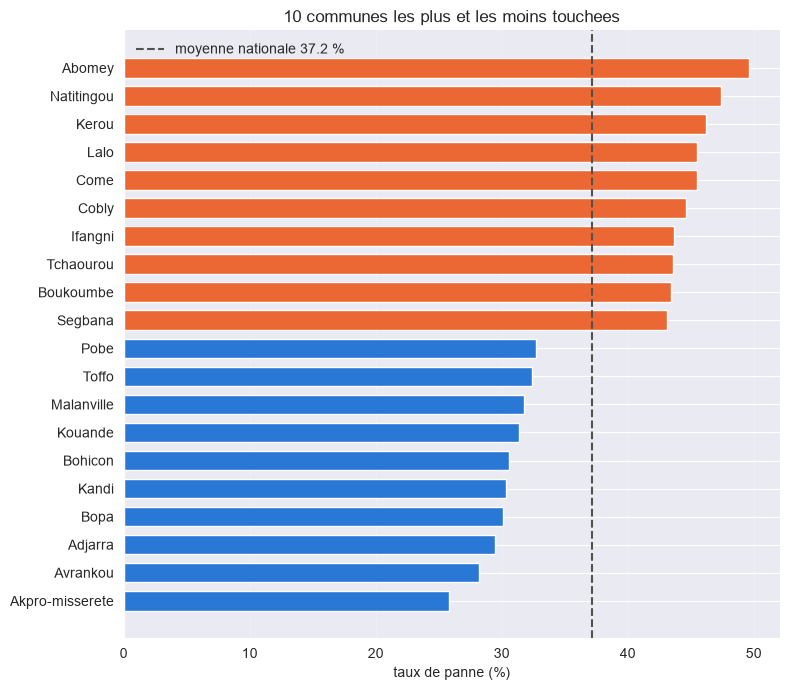

In [159]:
extremes = pd.concat([taux_commune.head(10), taux_commune.tail(10)])

fig, ax = plt.subplots(figsize=(8, 7))
couleurs = ["#eb6834" if v > moyenne else "#2a78d6" for v in extremes.taux_panne]
ax.barh(extremes.index[::-1], extremes.taux_panne[::-1], color=couleurs[::-1], height=.7)
ax.axvline(moyenne, ls="--", color="#52514e", lw=1.5,
           label=f"moyenne nationale {moyenne:.1f} %")
ax.set(title="10 communes les plus et les moins touchees", xlabel="taux de panne (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=.2); ax.set_axisbelow(True)
ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("../reports/b5_communes.png", dpi=150, bbox_inches="tight")


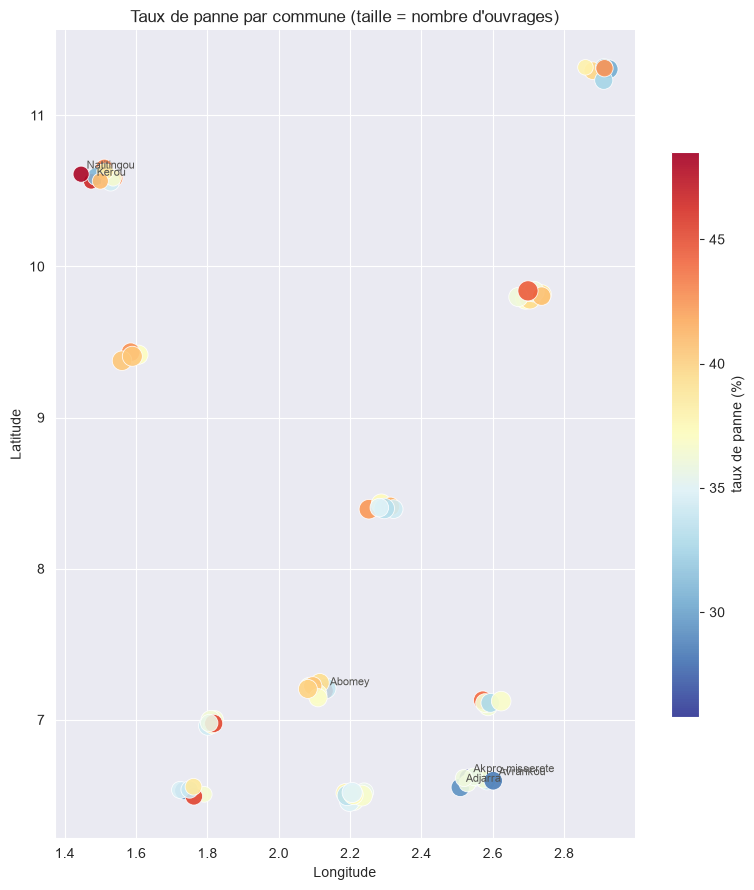

In [160]:

geo = (df.dropna(subset=["latitude", "longitude"])
         .groupby("commune")
         .agg(lat=("latitude", "mean"), lon=("longitude", "mean"),
              n=("en_panne", "size"), taux=("en_panne", "mean")))
geo["taux"] = geo["taux"] * 100

fig, ax = plt.subplots(figsize=(8, 9))
nuage = ax.scatter(geo.lon, geo.lat, s=geo.n * 1.2, c=geo.taux,
                   cmap="RdYlBu_r", edgecolor="white", linewidth=.6, alpha=.9)
plt.colorbar(nuage, ax=ax, label="taux de panne (%)", shrink=.7)

for nom in list(taux_commune.head(3).index) + list(taux_commune.tail(3).index):
    if nom in geo.index:
        ax.annotate(nom, (geo.loc[nom, "lon"], geo.loc[nom, "lat"]), fontsize=8,
                    color="#52514e", xytext=(4, 4), textcoords="offset points")

ax.set(title="Taux de panne par commune (taille = nombre d'ouvrages)",
       xlabel="Longitude", ylabel="Latitude")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(); fig.savefig("../reports/b5_carte.png", dpi=150, bbox_inches="tight")


In [161]:
print("--- Force du lien geographique ---")
for niveau in ["commune", "departement"]:
    tab = pd.crosstab(df[niveau], df["etat_fonctionnement"])
    chi2, p, _, _ = chi2_contingency(tab)
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    print(f"  {niveau:<12} V de Cramer {v:.3f}   p = {p:.4f}   ({df[niveau].nunique()} modalites)")

rng = np.random.default_rng(42)
observe = taux_commune.taux_panne.std()
simule = [df.assign(e=rng.permutation(df.en_panne.values))
            .groupby("commune").e.mean().mul(100).std() for _ in range(200)]
attendu, ecart = np.mean(simule), np.std(simule)
z = (observe - attendu) / ecart

print(f"\n--- Test de permutation (200 tirages) ---")
print(f"  ecart-type des taux : observe {observe:.2f} | au hasard {attendu:.2f} +/- {ecart:.2f}")
print(f"  ecart en z : {z:+.2f}")
print(f"  -> {'structure geographique reelle' if z > 2 else 'compatible avec le hasard'}")


--- Force du lien geographique ---
  commune      V de Cramer 0.089   p = 0.0367   (76 modalites)
  departement  V de Cramer 0.042   p = 0.0038   (11 modalites)

--- Test de permutation (200 tirages) ---
  ecart-type des taux : observe 4.58 | au hasard 3.95 +/- 0.32
  ecart en z : +1.92
  -> compatible avec le hasard


# B6. Installateur

In [162]:
def ic_wilson(succes, n, z=1.96):
    """Intervalle de confiance a 95 % d'une proportion, methode de Wilson.
    Preferee a l'IC normal : reste valide sur petits effectifs et taux extremes."""
    p = succes / n
    d = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / d
    demi = z * np.sqrt(p*(1-p)/n + z**2/(4*n**2)) / d
    return (centre - demi) * 100, (centre + demi) * 100


inst = df.groupby("installateur").agg(n=("en_panne", "size"), pannes=("en_panne", "sum"))
inst["taux"] = (inst.pannes / inst.n * 100).round(1)
inst["ic_bas"], inst["ic_haut"] = ic_wilson(inst.pannes, inst.n)
inst[["ic_bas", "ic_haut"]] = inst[["ic_bas", "ic_haut"]].round(1)
inst["largeur_ic"] = (inst.ic_haut - inst.ic_bas).round(1)

moyenne = df["en_panne"].mean() * 100
inst["ecart_significatif"] = (inst.ic_bas > moyenne) | (inst.ic_haut < moyenne)
inst = inst.sort_values("taux", ascending=False)

print(f"{len(inst)} installateurs | effectifs : min {inst.n.min()} · "
      f"median {int(inst.n.median())} · max {inst.n.max()}")
print(f"Aucun sous 50 ouvrages : {int((inst.n < 50).sum())} entreprise(s)")
print(f"IC excluant la moyenne nationale ({moyenne:.1f} %) : "
      f"{int(inst.ecart_significatif.sum())} / {len(inst)}")
display(pd.concat([inst.head(5), inst.tail(5)]))


52 installateurs | effectifs : min 186 · median 220 · max 251
Aucun sous 50 ouvrages : 0 entreprise(s)
IC excluant la moyenne nationale (37.2 %) : 20 / 52


,n,pannes,taux,ic_bas,ic_haut,largeur_ic,ecart_significatif
installateur,,,,,,,
Ent-042,229,122,53.3,46.8,59.6,12.8,True
Ent-005,201,103,51.2,44.4,58.1,13.7,True
Ent-016,234,115,49.1,42.8,55.5,12.7,True
Ent-001,209,99,47.4,40.7,54.1,13.4,True
Ent-043,212,97,45.8,39.2,52.5,13.3,True
Ent-017,220,59,26.8,21.4,33.0,11.6,True
Ent-011,251,66,26.3,21.2,32.1,10.9,True
Ent-013,207,54,26.1,20.6,32.5,11.9,True
Ent-025,205,47,22.9,17.7,29.1,11.4,True


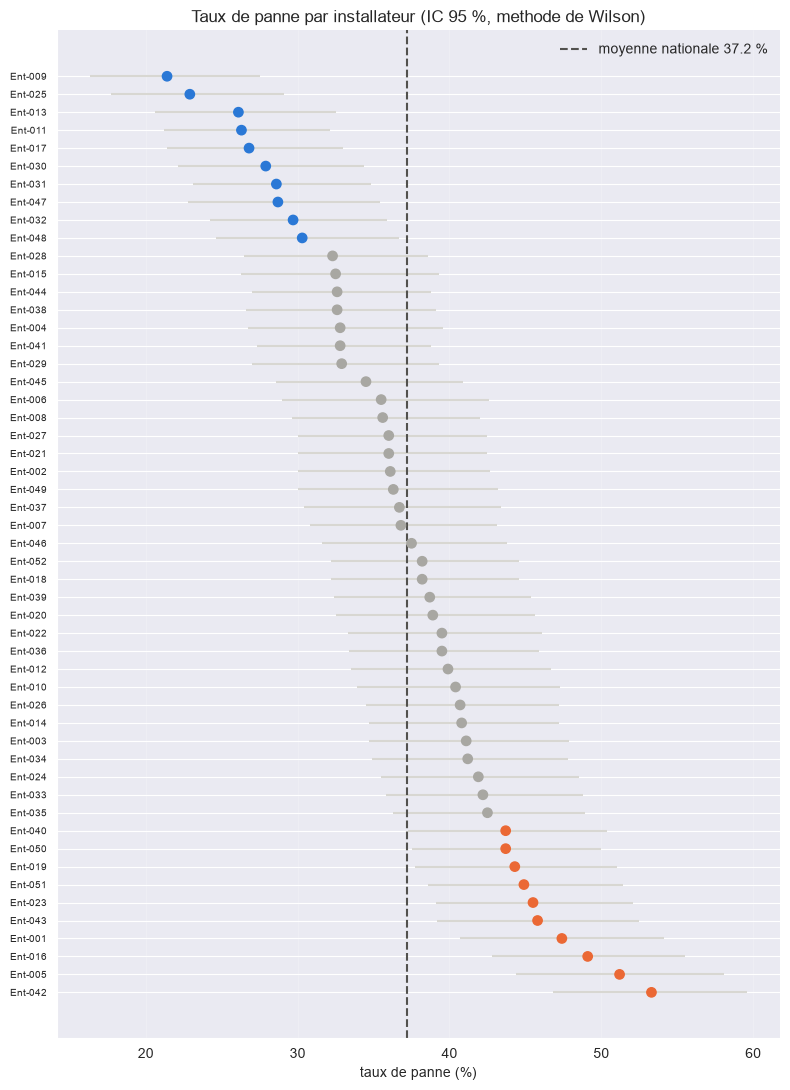

In [163]:
# --- Le graphique : chaque entreprise avec son intervalle de confiance ---
fig, ax = plt.subplots(figsize=(8, 11))
couleurs = ["#eb6834" if s and t > moyenne else "#2a78d6" if s else "#a8a7a2"
            for s, t in zip(inst.ecart_significatif, inst.taux)]
y = np.arange(len(inst))
ax.errorbar(inst.taux, y, xerr=[inst.taux - inst.ic_bas, inst.ic_haut - inst.taux],
            fmt="none", ecolor="#d8d7d2", lw=1.5)
ax.scatter(inst.taux, y, c=couleurs, s=45, zorder=3)
ax.axvline(moyenne, ls="--", color="#52514e", lw=1.5,
           label=f"moyenne nationale {moyenne:.1f} %")
ax.set_yticks(y, inst.index, fontsize=7)
ax.set(title="Taux de panne par installateur (IC 95 %, methode de Wilson)",
       xlabel="taux de panne (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=.2); ax.set_axisbelow(True); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig("../reports/b6_installateurs.png", dpi=150, bbox_inches="tight")


In [164]:
# --- Test de permutation : l'ecart depasse-t-il le hasard ? ---
tab = pd.crosstab(df.installateur, df.etat_fonctionnement)
chi2, p, ddl, _ = chi2_contingency(tab)
v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
print(f"V de Cramer : {v:.3f}   p = {p:.2e}   ({ddl} degres de liberte)")

rng = np.random.default_rng(42)
observe = inst.taux.std()
simule = [df.assign(e=rng.permutation(df.en_panne.values))
            .groupby("installateur").e.mean().mul(100).std() for _ in range(300)]
z = (observe - np.mean(simule)) / np.std(simule)
print(f"ecart-type des taux : observe {observe:.2f} | au hasard "
      f"{np.mean(simule):.2f} ± {np.std(simule):.2f} | z = {z:+.2f}")


V de Cramer : 0.148   p = 2.55e-53   (102 degres de liberte)
ecart-type des taux : observe 7.01 | au hasard 3.27 ± 0.32 | z = +11.60


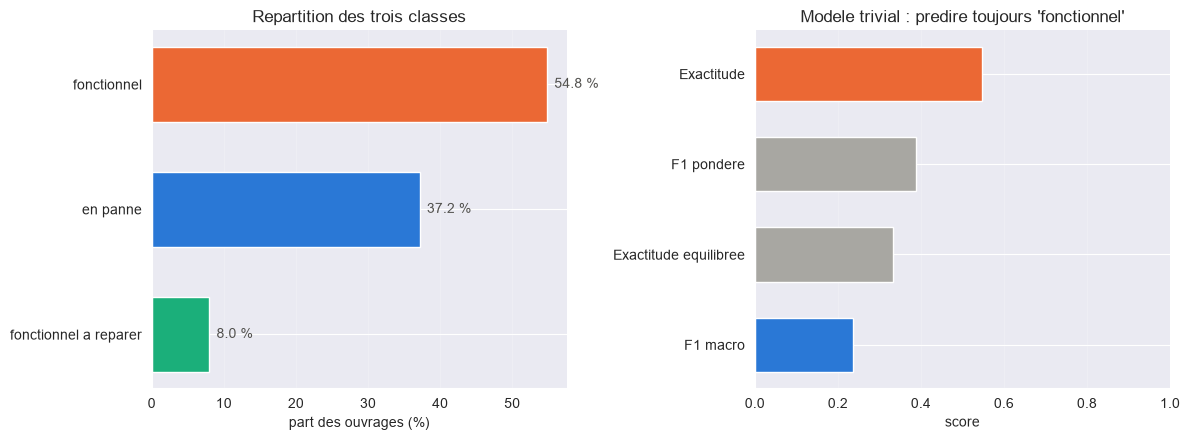

In [165]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

parts = df["etat_fonctionnement"].value_counts(normalize=True).mul(100)
axes[0].barh(parts.index[::-1], parts.values[::-1],
             color=["#eb6834", "#2a78d6", "#1baf7a"][::-1], height=.6)
for i, v in enumerate(parts.values[::-1]):
    axes[0].text(v + 1, i, f"{v:.1f} %", va="center", fontsize=10, color="#52514e")
axes[0].set(title="Repartition des trois classes", xlabel="part des ouvrages (%)")

metriques = {"Exactitude": 0.548, "F1 pondere": 0.389,
             "Exactitude equilibree": 0.333, "F1 macro": 0.236}
axes[1].barh(list(metriques)[::-1], list(metriques.values())[::-1],
             color=["#eb6834", "#a8a7a2", "#a8a7a2", "#2a78d6"][::-1], height=.6)
axes[1].set(title="Modele trivial : predire toujours 'fonctionnel'", xlabel="score", xlim=(0, 1))

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", alpha=.2); ax.set_axisbelow(True)
fig.tight_layout(); fig.savefig("../reports/b1_classes.png", dpi=150, bbox_inches="tight")


# Partie C.  Préparation des variables

# C1.  creation de variable

In [170]:
df_propre = nettoyer(pd.read_csv("../data/points_eau.csv"))
df = preparer(pd.read_csv("../data/points_eau.csv"))

DERIVEES = [c for c in df.columns if c not in df_propre.columns]
print(f"{df_propre.shape[1]} colonnes -> {df.shape[1]} ({len(DERIVEES)} creees)")
print(DERIVEES)
display(df[DERIVEES].describe().T[["count", "mean", "50%", "max"]].round(3))


29 colonnes -> 43 (14 creees)
['age_ans', 'pression_usage', 'ratio_niveau_statique', 'capacite_entretien', 'coordonnees_manquantes', 'annee_inconnue', 'population_inconnue', 'debit_inconnu', 'pannes_par_an', 'distance_atelier_relative', 'appui_technique', 'debit_par_personne', 'mois_releve', 'trimestre_releve']


,count,mean,50%,max
age_ans,11234.0,21.824,22.000,43.000
pression_usage,11307.0,0.621,0.437,10.740
ratio_niveau_statique,9657.0,0.373,0.360,0.954
capacite_entretien,11402.0,2.813,3.000,4.000
coordonnees_manquantes,11402.0,0.019,0.000,1.000
annee_inconnue,11402.0,0.015,0.000,1.000
population_inconnue,11402.0,0.008,0.000,1.000
debit_inconnu,11402.0,0.098,0.000,1.000
pannes_par_an,11234.0,0.084,0.053,3.000
distance_atelier_relative,11402.0,1.175,1.000,7.148


# C2. Haute cardinalité

etat_fonctionnement,en panne,fonctionnel,fonctionnel a reparer,n
capacite_entretien,,,,
0,74.2,22.5,3.3,854
1,56.2,35.1,8.7,1455
2,41.2,48.1,10.7,1056
3,41.7,52.9,5.4,3643
4,18.9,70.9,10.2,4394


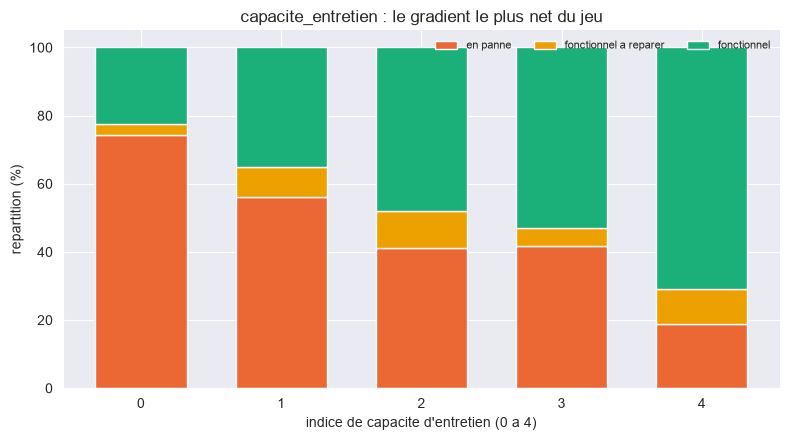

In [171]:
profil = pd.crosstab(df["capacite_entretien"], df["etat_fonctionnement"],
                     normalize="index").mul(100).round(1)
profil["n"] = df["capacite_entretien"].value_counts()
display(profil)

fig, ax = plt.subplots(figsize=(8, 4.5))
bas = np.zeros(len(profil))
for classe, couleur in [("en panne", "#eb6834"), ("fonctionnel a reparer", "#eda100"),
                        ("fonctionnel", "#1baf7a")]:
    ax.bar(profil.index.astype(str), profil[classe], bottom=bas, color=couleur,
           label=classe, width=.65)
    bas += profil[classe].values
ax.set(title="capacite_entretien : le gradient le plus net du jeu",
       xlabel="indice de capacite d'entretien (0 a 4)", ylabel="repartition (%)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, ncol=3)
fig.tight_layout(); fig.savefig("../reports/c1_capacite_entretien.png", dpi=150, bbox_inches="tight")


In [172]:
from scipy.stats import chi2_contingency

def v_cramer_num(serie, cible, n_tranches=8):
    """V de Cramer sur une variable numerique decoupee en tranches."""
    d = pd.DataFrame({"x": serie, "y": cible}).dropna()
    tab = pd.crosstab(pd.qcut(d.x, n_tranches, duplicates="drop"), d.y)
    chi2 = chi2_contingency(tab)[0]
    return np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))

classement = pd.DataFrame([
    {"variable": c, "v_cramer": round(v_cramer_num(df[c], df["etat_fonctionnement"]), 3)}
    for c in DERIVEES if df[c].nunique() > 2
]).sort_values("v_cramer", ascending=False)
display(classement)


,variable,v_cramer
6,appui_technique,0.330
0,age_ans,0.247
3,capacite_entretien,0.245
4,pannes_par_an,0.165
1,pression_usage,0.062
5,distance_atelier_relative,0.059
7,debit_par_personne,0.052
8,mois_releve,0.028
2,ratio_niveau_statique,0.016
9,trimestre_releve,0.014


### C2 et C3 dans `src/train.py`

Ces deux consignes exigent d'entraîner des modèles : elles sont donc dans
`src/train.py`, pas ici.

```bash
python src/train.py    # C2, C3, experience de fuite, D2 a D7
